# PlantVillage Dataset – Exploratory Data Analysis (EDA)

This notebook performs an exploratory analysis of the PlantVillage dataset focusing on:
1. Class distribution and imbalance analysis  
2. Image resolution and aspect ratio analysis  

The goal is to understand dataset characteristics before model training.

IMPORT REQUIRED LIBRARIES

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

DATASET PATH & CLASS DISCOVERY

In [2]:
DATASET_PATH = "datasets/plantvillage dataset/color"

class_names = sorted(os.listdir(DATASET_PATH))
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Sample classes:", class_names[:5])

Number of classes: 38
Sample classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


CLASS DISTRIBUTION

In [8]:
# Count number of images per class
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(DATASET_PATH, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

# Create DataFrame
class_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Image_Count"]
)

# Sort by image count (descending) for better analysis
class_df = class_df.sort_values(by="Image_Count", ascending=False).reset_index(drop=True)

# Display full class distribution
class_df

,Class,Image_Count
0,Orange___Haunglongbing_(Citrus_greening),5507
1,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
2,Soybean___healthy,5090
3,Peach___Bacterial_spot,2297
4,Tomato___Bacterial_spot,2127
5,Tomato___Late_blight,1909
6,Squash___Powdery_mildew,1835
7,Tomato___Septoria_leaf_spot,1771
8,Tomato___Spider_mites Two-spotted_spider_mite,1676
9,Apple___healthy,1645


CLASS DISTRIBUTION PLOT

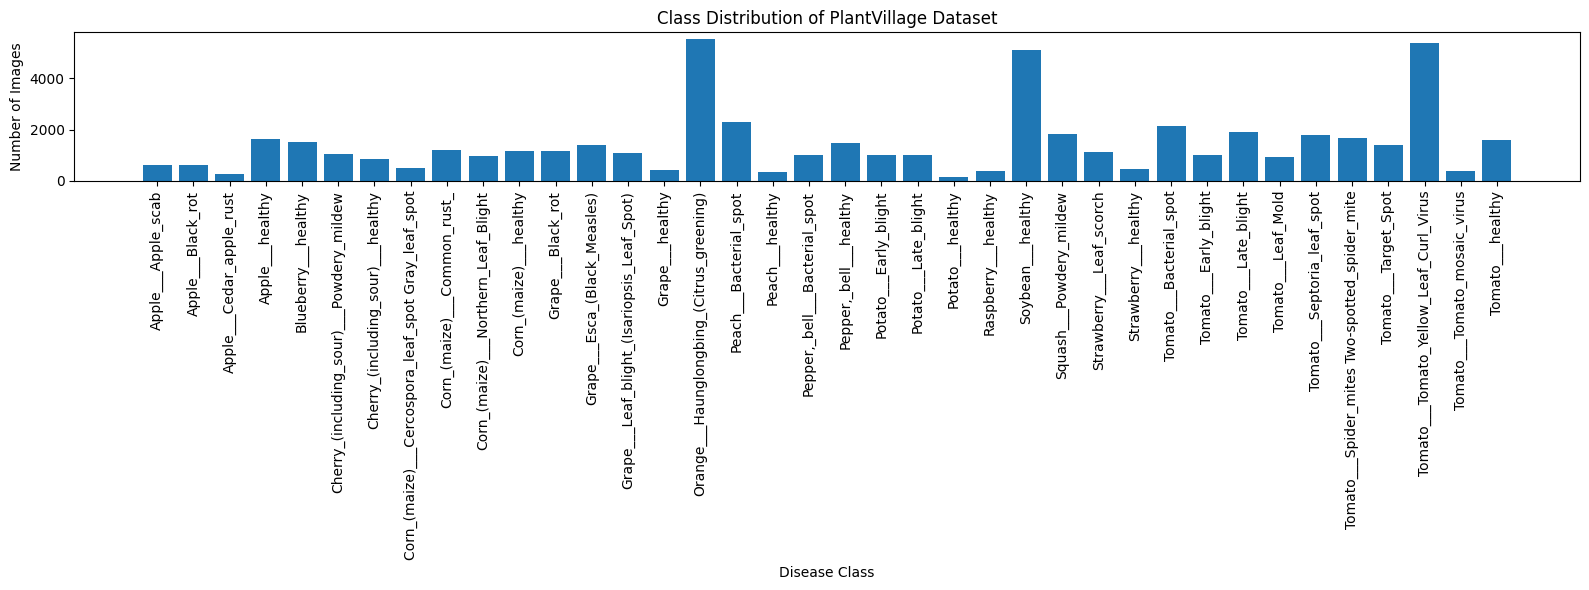

In [4]:
plt.figure(figsize=(16, 6))
plt.bar(class_df["Class"], class_df["Image_Count"])
plt.xticks(rotation=90)
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution of PlantVillage Dataset")
plt.tight_layout()
plt.show()

IMAGE RESOLUTION ANALYSIS

In [5]:
widths = []
heights = []

sample_limit = 200  # enough for statistical insight

for class_name in class_names:
    class_path = os.path.join(DATASET_PATH, class_name)
    images = os.listdir(class_path)[:sample_limit]

    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            h, w, _ = img.shape
            heights.append(h)
            widths.append(w)

print("Height stats:", min(heights), max(heights))
print("Width stats:", min(widths), max(widths))

Height stats: 256 256
Width stats: 256 256


IMAGE DIMENSION DISTRIBUTION

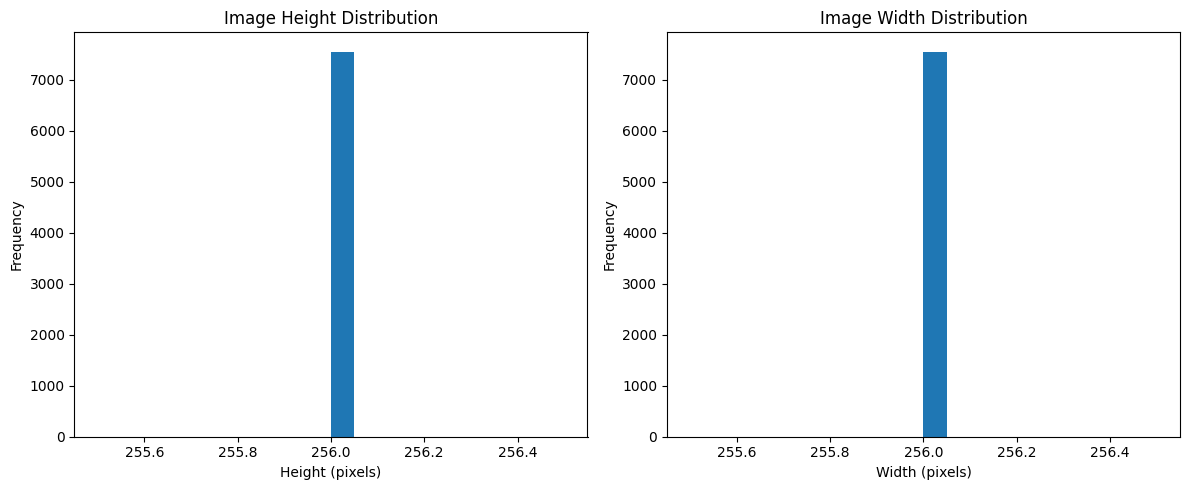

In [6]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

ASPECT RATIO ANALYSIS

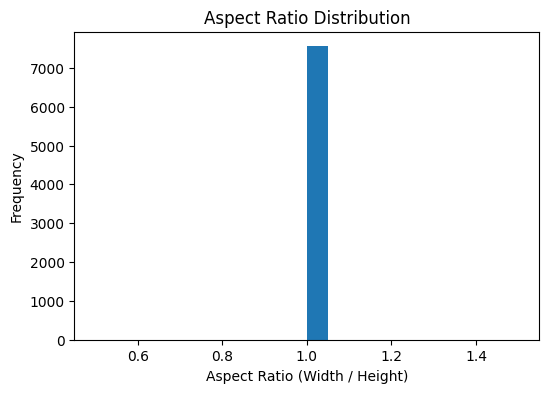

Aspect ratio range: 1.0 1.0


In [7]:
aspect_ratios = [w/h for w, h in zip(widths, heights)]

plt.figure(figsize=(6,4))
plt.hist(aspect_ratios, bins=20)
plt.xlabel("Aspect Ratio (Width / Height)")
plt.ylabel("Frequency")
plt.title("Aspect Ratio Distribution")
plt.show()

print("Aspect ratio range:", min(aspect_ratios), max(aspect_ratios))

EDA Observations

- The dataset contains multiple disease categories with noticeable class imbalance.
- Some classes have significantly more images than others.
- Image dimensions are largely consistent, with minor variations.
- Aspect ratios are mostly uniform, indicating minimal distortion risk.
- Preprocessing steps such as resizing to 224×224 and normalization are required.
- Class imbalance handling techniques will be necessary during training.